This notebook is intended as an an active testing ground where all data is loaded and simple plots are made to investigate them and identify any issues.

In [4]:
import sys
sys.path.append("../src")
from data_ETL_functions import *

data_dir = "../data/synthetic/mock_"

# Biometrics
weight_df = load_weight(file=f"{data_dir}cronometer_weight.csv")

sleep_df = load_sleep(file=f"{data_dir}cronometer_sleep.csv")

hr_df = load_hr(file=f"{data_dir}cronometer_heartrate.csv")

food_df = load_food(file=f"{data_dir}cronometer_food.csv")

bodyfat_df = load_bf(file=f"{data_dir}cronometer_bodyfat.csv")

# Training Log
sessions_df = load_sessions(file=f"{data_dir}training.xlsx")

strength_df = load_strength_log(file=f"{data_dir}training.xlsx")

# carido_df = load_cardio_log(file=f"{data_dir}training.xlsx")    # no features for this yet, do not read in

# mobility_df = load_mobility_log(file=f"{data_dir}training.xlsx")    # no features for this yet, do not read in

exercise_lookup_df = load_exercise_lookup(file=f"{data_dir}training.xlsx")


In [5]:
import matplotlib.pyplot as plt

# Generic plotting function
def plot_df(df, x, y, title=""):
    plt.figure(figsize=(10,5))
    plt.plot(df[x], df[y])
    plt.xlabel(f"{x}")
    plt.ylabel(f"{y}")
    plt.title(title)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Plots
## Bodyweight

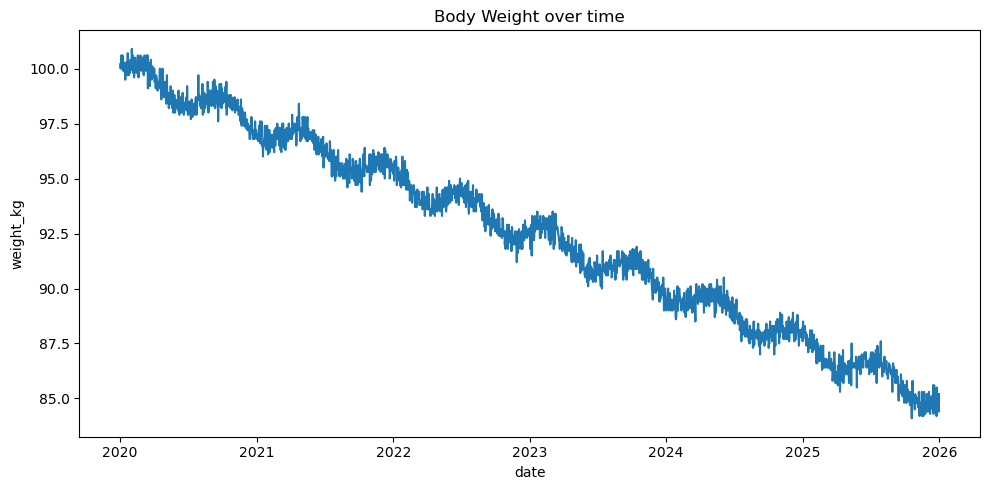

In [6]:
import numpy as np

plot_df(weight_df, "date", "weight_kg", title="Body Weight over time")

## Heart Rate

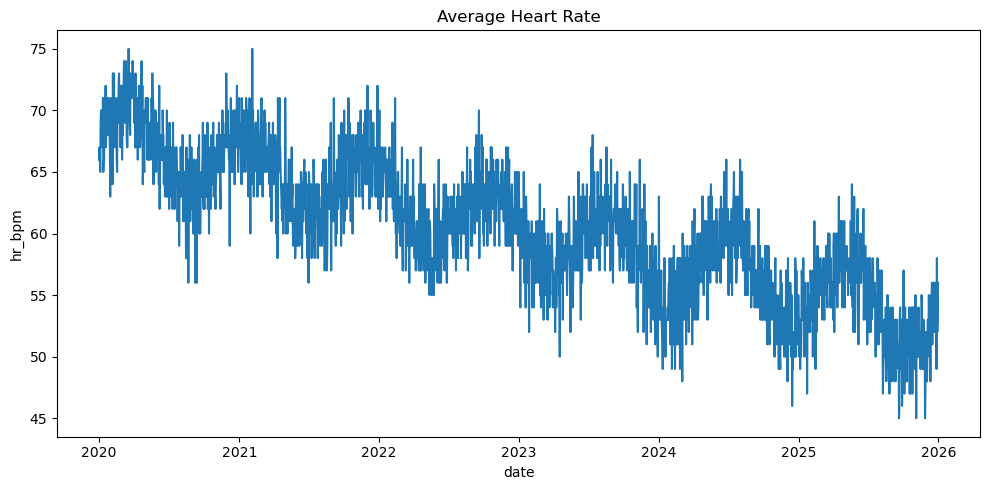

In [7]:
plot_df(hr_df, "date", "hr_bpm", title="Average Heart Rate")

## Sleep

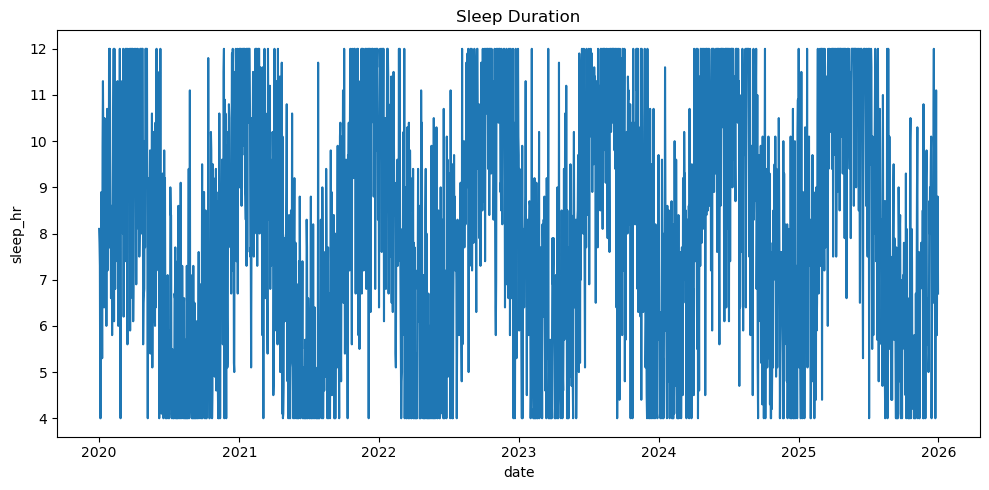

In [8]:
plot_df(sleep_df, "date", "sleep_hr", title="Sleep Duration")

## Body fat

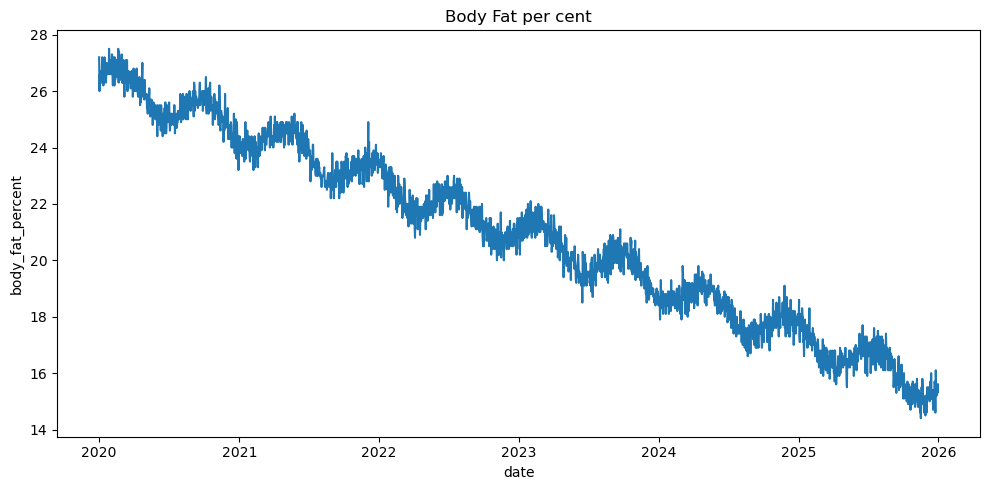

In [9]:
plot_df(bodyfat_df, "date", "body_fat_percent", title="Body Fat per cent")

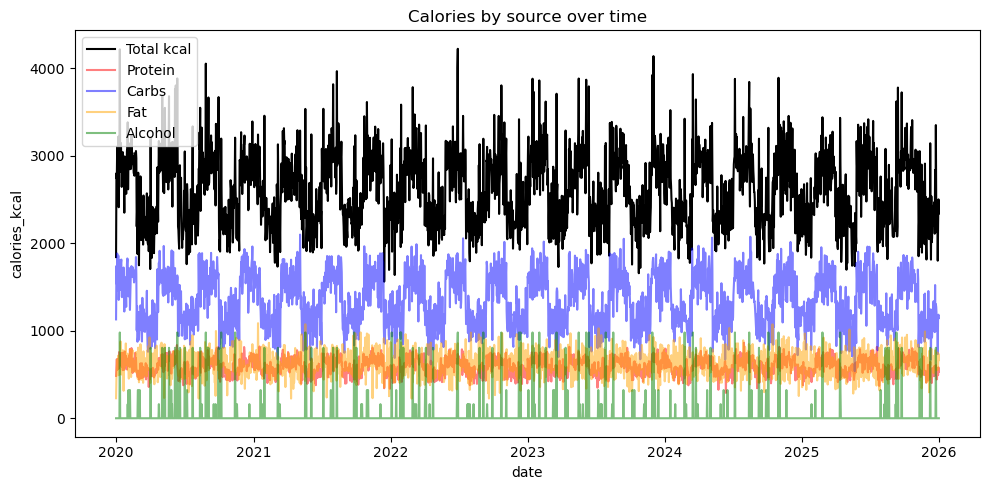

In [12]:
# Filter out days with no, or incomplete, entires
calorie_filter = np.where(food_df["calories_kcal"] > 500)[0]
date = (food_df["date"])[calorie_filter]
calories = (food_df["calories_kcal"])[calorie_filter]
alcohol = (food_df["alcohol_g"])[calorie_filter]
protein = (food_df["protein_g"])[calorie_filter]
carbs = (food_df["carbs_g"])[calorie_filter]
fat = (food_df["fat_g"])[calorie_filter]

plt.figure(figsize=(10,5))

plt.plot(date, calories, c="k", label="Total kcal")
plt.plot(date, protein*4., c="red",alpha=0.5, label="Protein")
plt.plot(date, carbs*4, c="blue",alpha=0.5, label="Carbs")
plt.plot(date, fat*9, c="orange",alpha=0.5, label="Fat")
plt.plot(date, alcohol*7, c="green", alpha=0.5, label="Alcohol")

plt.xlabel(f"date")
plt.ylabel(f"calories_kcal")
plt.title("Calories by source over time")
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()